In [ ]:
!pip install pandas matplotlib gdown

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import gdown
import os

In [3]:
# Download data from Google Sheets using gdown
sheet_id = '1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ'
gid_baseline = '1387240715' 
gid_fractal = '1558614809'
url_baseline = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid_baseline}'
url_fractal = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid_fractal}'

baseline_csv = 'baseline_data.csv'
fractal_csv = 'fractal_data.csv'

# Download files if they don't exist in the current directory
if not os.path.exists(baseline_csv):
    gdown.download(url_baseline, baseline_csv, quiet=False)
if not os.path.exists(fractal_csv):
    gdown.download(url_fractal, fractal_csv, quiet=False)

/home/diogoocv/miniconda3/envs/SMAC/lib/python3.10/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=1387240715
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/baseline_data.csv
1.34kB [00:00, 1.75MB/s]
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=1558614809
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/fractal_data.csv
25.9kB [00:00, 3.30MB/s]


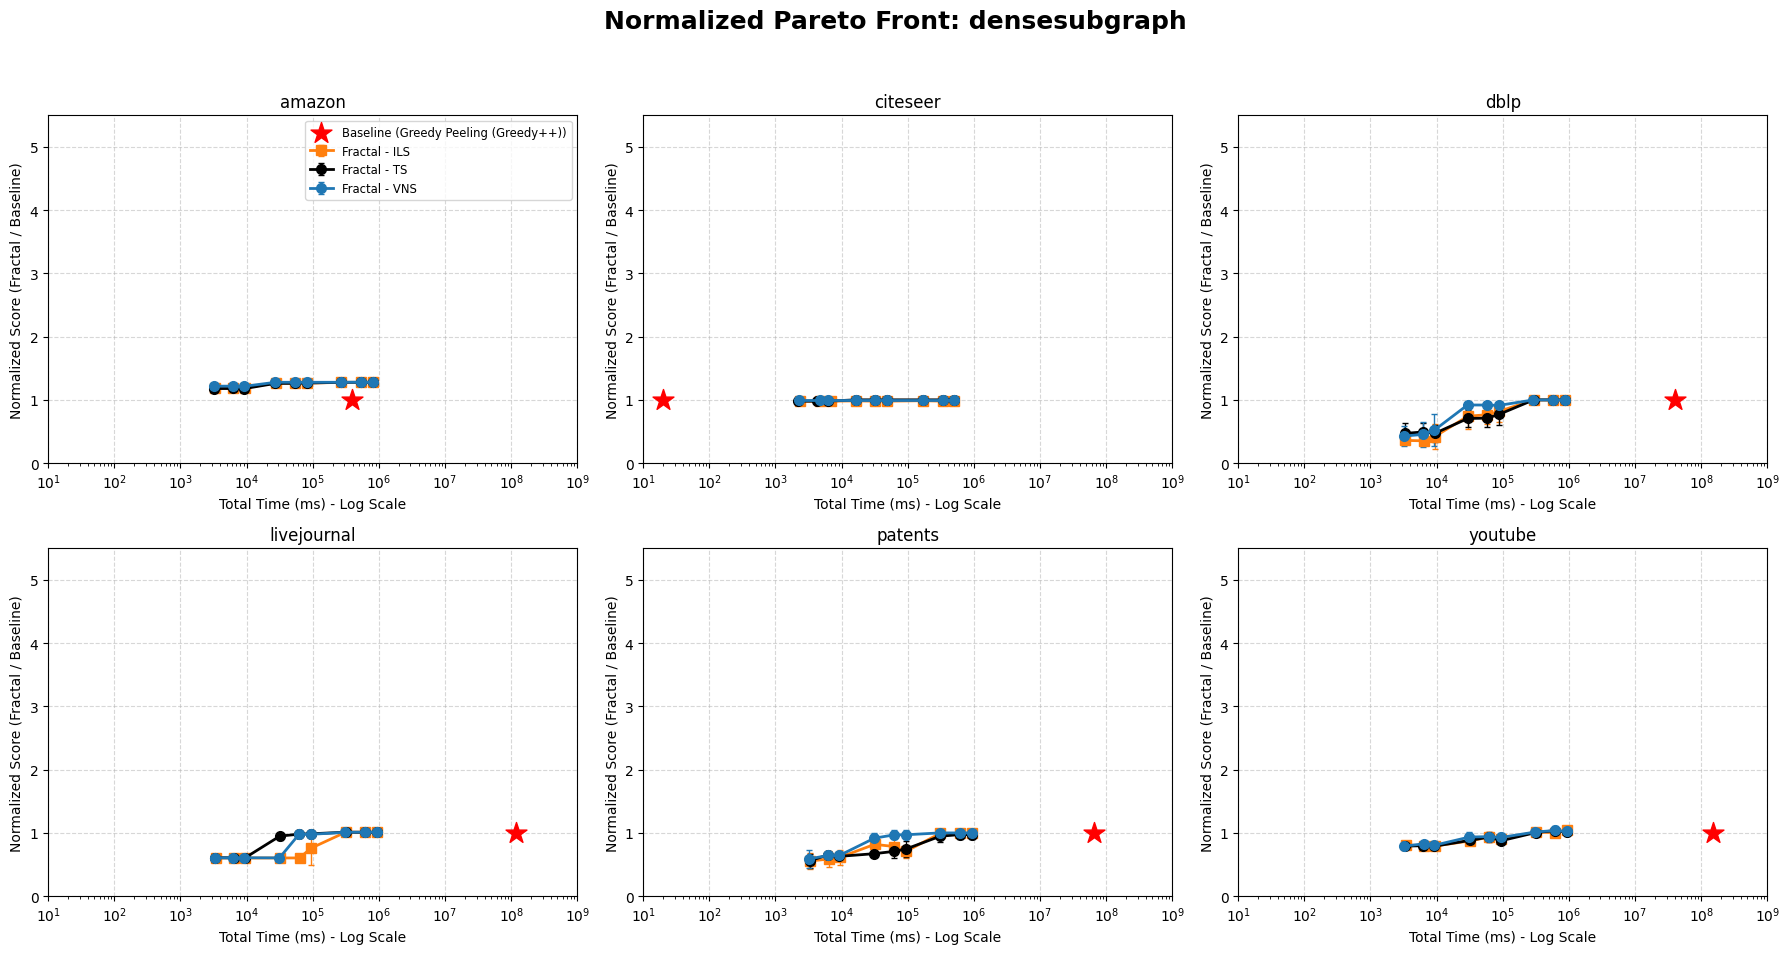

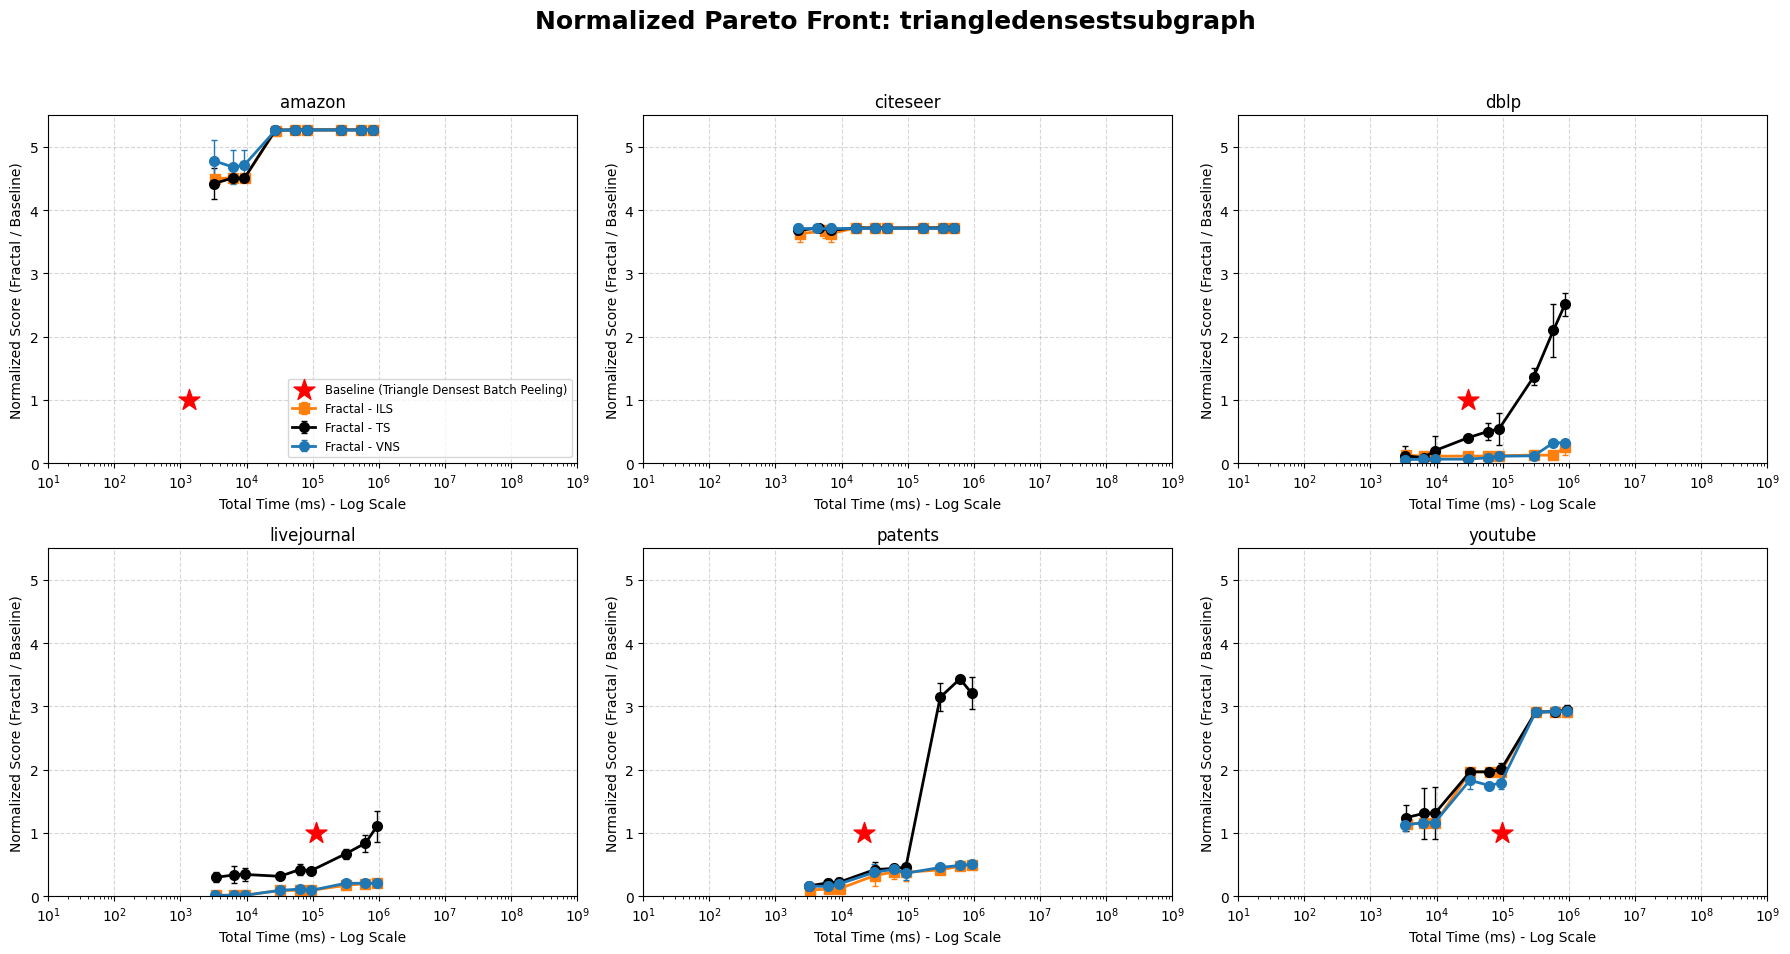

In [27]:
# Load the data
df_baseline = pd.read_csv(baseline_csv)
df_fractal = pd.read_csv(fractal_csv)

# Clean up column names
df_baseline.columns = df_baseline.columns.astype(str).str.strip().str.lower().str.replace(' ', '_')
df_fractal.columns = df_fractal.columns.astype(str).str.strip().str.lower().str.replace(' ', '_')

# Drop duplicated
df_baseline = df_baseline.loc[:, ~df_baseline.columns.duplicated()]
df_fractal = df_fractal.loc[:, ~df_fractal.columns.duplicated()]

# Clean up stray unnamed columns
df_fractal = df_fractal.loc[:, ~df_fractal.columns.str.contains('unnamed')]

# Define mapping
baseline_mapping = {
    'densesubgraph': 'Greedy Peeling (Greedy++)',
    'triangledensestsubgraph': 'Triangle Densest Batch Peeling'
}

df_fractal['metaheuristic'] = df_fractal['metaheuristic'].replace({'ts1': 'ts'})
df_fractal_filtered = df_fractal.copy()

# Sort by time
df_fractal_filtered.sort_values(by=['graph_name', 'objective_function', 'metaheuristic', 'average_of_total_time_ms'], inplace=True)

# Define standard styling
graphs = ['amazon', 'citeseer', 'dblp', 'livejournal', 'patents', 'youtube']
metaheuristics = df_fractal_filtered['metaheuristic'].unique()
colors = {'vns': '#1f77b4', 'ils': '#ff7f0e', 'ts1': '#2ca02c'}
markers = {'vns': 'o', 'ils': 's', 'ts1': '^'}

# Generate the plots
for obj_func, baseline_alg in baseline_mapping.items():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Normalized Pareto Front: {obj_func}', fontsize=18, weight='bold')
    axes = axes.flatten()
    
    for i, graph in enumerate(graphs):
        ax = axes[i]
        ax.set_title(f'{graph}')
        ax.set_xlabel('Total Time (ms) - Log Scale')
        ax.set_ylabel('Normalized Score (Fractal / Baseline)')
        ax.set_xlim(10**1, 10**9)
        ax.set_ylim(0, 5.5)
        
        # Use log scale for X due to massive differences in runtime
        ax.set_xscale('log') 
        
        # Plot Baseline
        baseline_data = df_baseline[(df_baseline['objective_function'] == obj_func) & 
                                    (df_baseline['algorithm'] == baseline_alg) & 
                                    (df_baseline['graph'] == graph)]
        
        if not baseline_data.empty:
            # Extract Baseline score and time
            baseline_score = baseline_data['cost_best_solution'].values[0]
            baseline_time = baseline_data['total_time_(ms)'].values[0]
            
            # Plot Baseline at exactly Y = 1.0
            ax.scatter(baseline_time, 
                       1.0, 
                       color='red', marker='*', s=250, label=f'Baseline ({baseline_alg})', zorder=5)
            
            # Plot Metaheuristics
            for meta in metaheuristics:
                meta_data = df_fractal_filtered[(df_fractal_filtered['objective_function'] == obj_func) & 
                                                (df_fractal_filtered['metaheuristic'] == meta) & 
                                                (df_fractal_filtered['graph_name'] == graph)]
                
                if not meta_data.empty:
                    # Normalize the score!
                    normalized_score = meta_data['average_of_cost_best_solution'] / baseline_score
                    normalized_ci = meta_data['ci_cost'] / baseline_score

                    # Draw the CI
                    ax.errorbar(
                        meta_data['average_of_total_time_ms'],
                        normalized_score,
                        yerr=normalized_ci,
                        color=colors.get(meta, 'black'),
                        marker=markers.get(meta, 'o'),
                        markersize=7,
                        linestyle='-',
                        linewidth=2,
                        elinewidth=1,
                        capsize=2,
                        alpha=1,
                        label=(f"Fractal - {meta.upper()}")
                    )
                    

        ax.grid(True, which="major", ls="--", alpha=0.5)
        
        # Add legend only to the first subplot
        if i == 0:  
            ax.legend(loc='best', fontsize='small')

    # Create directory
    output_dir = 'pareto_plots'
    os.makedirs(output_dir, exist_ok=True)
    filename = f'pareto_quality_time_{obj_func}.pdf'
    full_path = os.path.join(output_dir, filename)
    
    # Save the file
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(full_path, dpi=300, bbox_inches='tight')
    plt.show()